# Chapter 9 — Spin-resolved DOS of bcc iron

Companion notebook to Chapter 9. We plot the majority (↑) and minority (↓)
densities of states of ferromagnetic bcc Fe (`code/09-magnetism/fe.dos`),
aligned to the Fermi level. The shift between the two channels is the
exchange splitting, and their occupied-area imbalance is the magnetic
moment. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np, re
from pathlib import Path

d = Path('../code/09-magnetism')
head = (d/'fe.dos').read_text().splitlines()[0]
EF = float(re.search(r'EFermi\s*=\s*([-0-9.]+)', head).group(1))
# nspin=2 dos.x columns: E, dos_up, dos_dn, int_dos
E, up, dn, idos = np.loadtxt(d/'fe.dos', unpack=True)
E = E - EF
print(f'EFermi = {EF:.3f} eV  -> 0')
# moment estimate: integral of (up - dn) over occupied (E<0)
occ = E < 0
dE = E[1]-E[0]
m = np.sum((up[occ]-dn[occ]))*dE
print(f'∫(up-dn) over occupied ≈ {m:.2f} μB  (cf. total magnetization 2.23 μB)')

EFermi = 17.387 eV  -> 0
∫(up-dn) over occupied ≈ 2.22 μB  (cf. total magnetization 2.23 μB)


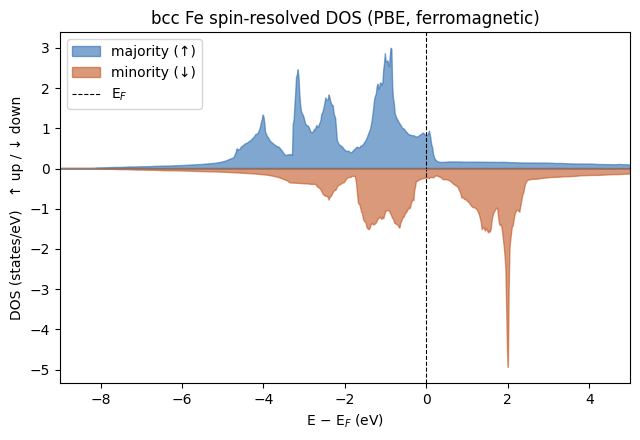

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.fill_between(E, up,  0, color='#2b6cb0', alpha=0.6, label='majority (↑)')
ax.fill_between(E, -dn, 0, color='#c05621', alpha=0.6, label='minority (↓)')
ax.axvline(0, color='k', ls='--', lw=0.8, label='E$_F$')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlim(-9, 5)
ax.set_xlabel('E − E$_F$ (eV)')
ax.set_ylabel('DOS (states/eV)   ↑ up / ↓ down')
ax.set_title('bcc Fe spin-resolved DOS (PBE, ferromagnetic)')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/09-fe-dos.png', dpi=120)
plt.show()

**What you see.** The majority (↑) 3d band sits **lower** and is almost
completely filled below $E_F$; the minority (↓) band is pushed **up** by
the exchange splitting and is only partly filled. The leftover imbalance —
more occupied ↑ than ↓ states — is the **2.2 μB** moment. This rigid
up/down shift is the Stoner picture of itinerant ferromagnetism, read
straight off the DOS.